In [2]:
import pandas as pd

df = pd.read_csv("~/projects/student_analysis/student_dataset.csv")

print(df.shape)
print(df.dtypes)
df.head()

(6607, 11)
Hours_Studied                 float64
Attendance                    float64
Parental_Involvement              str
Access_to_Resources               str
Extracurricular_Activities        str
Sleep_Hours                   float64
Previous_Scores               float64
Motivation_Level                  str
Internet_Access                   str
Tutoring_Sessions               int64
Final_Exam_Score              float64
dtype: object


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


In [3]:
print(df.isnull().sum())
print("---")
print(df.describe())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Final_Exam_Score              0
dtype: int64
---
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000  6607.000000      6607.000000   
mean       20.472726    79.979068     7.185273        74.716059   
std         5.988729    11.547717     1.290241        14.451962   
min         1.100000    60.000000     4.000000        50.000000   
25%        16.500000    70.000000     6.300000        62.100000   
50%        20.500000    79.800000     7.200000        74.600000   
75%        24.500000    90.200000     8.100000        87.400000   
max        44.000000   100.000000    10.000000       100.000000   

       Tutoring_Sessions  F

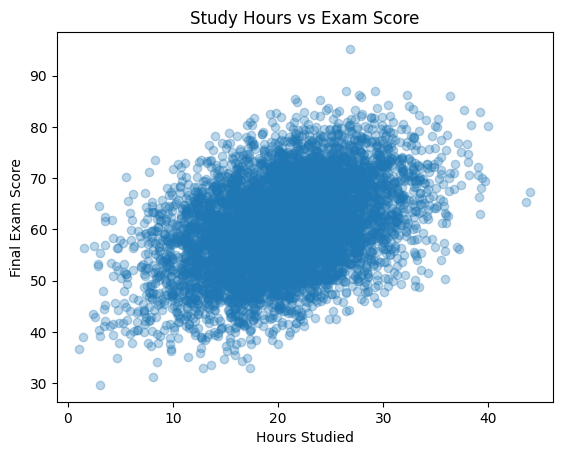

0.4098502101929742


In [4]:
# Does studying more hourse imporve scores?

import matplotlib.pyplot as plt

plt.scatter(df["Hours_Studied"], df["Final_Exam_Score"], alpha=0.3)
plt.xlabel("Hours Studied")
plt.ylabel("Final Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

print(df["Hours_Studied"].corr(df["Final_Exam_Score"]))

            

In [5]:
# Does parental involvement matter?
df.groupby("Parental_Involvement")["Final_Exam_Score"].mean().sort_values()

Parental_Involvement
High      60.251728
Medium    60.449747
Low       60.499372
Name: Final_Exam_Score, dtype: float64

In [6]:
# Does motivation level afect scores?
df.groupby("Motivation_Level")["Final_Exam_Score"].mean().sort_values()

Motivation_Level
Low       57.541645
Medium    60.595747
High      63.938473
Name: Final_Exam_Score, dtype: float64

In [7]:
# check ALL numeric correlations at once
df[["Hours_Studied", "Attendance", "Sleep_Hours", 
    "Previous_Scores", "Tutoring_Sessions", "Final_Exam_Score"]].corr()["Final_Exam_Score"].sort_values(ascending=False)

Final_Exam_Score     1.000000
Previous_Scores      0.653388
Hours_Studied        0.409850
Attendance           0.266152
Tutoring_Sessions    0.207310
Sleep_Hours         -0.012736
Name: Final_Exam_Score, dtype: float64

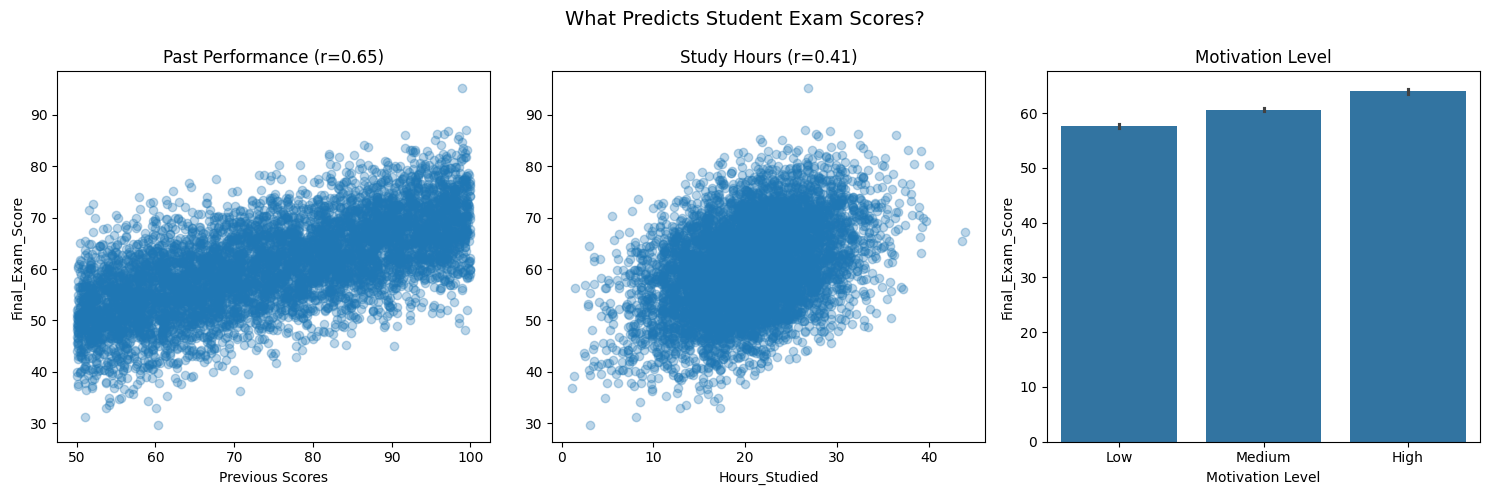

In [9]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15,5))
fig.suptitle("What Predicts Student Exam Scores?", fontsize=14)

# prev scores vs final score
axes[0].scatter(df["Previous_Scores"], df["Final_Exam_Score"], alpha=0.3)
axes[0].set_xlabel("Previous Scores")
axes[0].set_ylabel("Final_Exam_Score")
axes[0].set_title("Past Performance (r=0.65)")

# Hours studied vs final score
axes[1].scatter(df["Hours_Studied"], df["Final_Exam_Score"], alpha=0.3)
axes[1].set_xlabel("Hours_Studied")
axes[1].set_title("Study Hours (r=0.41)")

# Motivation level
motivation_order = ["Low", "Medium", "High"]
sns.barplot(data=df, x="Motivation_Level", y="Final_Exam_Score", order=motivation_order, ax=axes[2])
axes[2].set_title("Motivation Level")
axes[2].set_xlabel("Motivation Level")

plt.tight_layout()
plt.savefig("exam_score_analysis.png", dpi=150)
plt.show()